In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
c1 = pd.read_csv('../data/pOXA48/plate_counts.tsv', sep='\t')
c2 = pd.read_csv('../data/PN23/plate_counts.tsv', sep='\t')

In [4]:
# TODO: when new PN23 rep is ready, add it to this dataframe
c1 = c1[~((c1['vial'] == 'M0') & (c1['replicate'] == 'rep1'))].reset_index(drop=True)

In [5]:
for df in [c1, c2]:
    df['replicate'] = df['replicate'].astype(str).str.replace('rep', '')

In [6]:
m1 = pd.read_csv('../data/pOXA48/chibio.tsv.gz', sep='\t')
m2 = pd.read_csv('../data/PN23/chibio.tsv.gz', sep='\t')

In [7]:
# TODO: when new PN23 rep is ready, add it to this dataframe
m1 = m1[~((m1['vial'] == 'M0') & (m1['replicate'] == 'rep1'))].reset_index(drop=True)

In [8]:
for df in [m1, m2]:
    df['replicate'] = df['replicate'].astype(str).str.replace('rep', '')

In [9]:
short = ['KAN 16x MIC',
         'PVI 16x MIC',
         'PVB 16x MIC']

In [10]:
order = ['KAN',
         'PVI',
         'PVB']

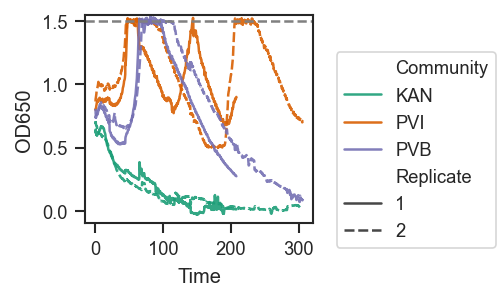

In [11]:
cp = sns.relplot(data=m1[m1['short'].isin(short)].rename(
    columns={'replicate': 'Replicate',
             'plasmid': 'Community'}),
                 x='time',
                 y='smooth_od',
                 style='Replicate',
                 style_order=['1', '2'],
                 hue='Community',
                 hue_order=order,
                 palette='Dark2',
                 kind='line',
                 height=2.1, aspect=1.1,
                 alpha=0.9,
                 # legend=False
                )

cp.set(
    xlabel='Time',
    ylabel='OD650',
    ylim=(-0.1, 1.55),
    xlim=(np.float64(-15.251309999999998), np.float64(321.74674333333326))
)
cp.set_titles("")
cp.map(plt.axhline, y=1.5, color='grey', linestyle='--')

sns.despine(right=False, top=False)

cp._legend.set_frame_on(True)
cp._legend.get_frame().set_facecolor('white')

plt.savefig('pvb_chibio_od.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pvb_chibio_od.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [12]:
ct = c1.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time', 'plate']).apply(
               lambda x: x['CFU/mL'].sum(),
               include_groups=False).reset_index().rename(columns={0: 'CFU/mL'})
ct['CFU/mL'] = ct['CFU/mL'].apply(lambda x: 100 if x < 100 else x)

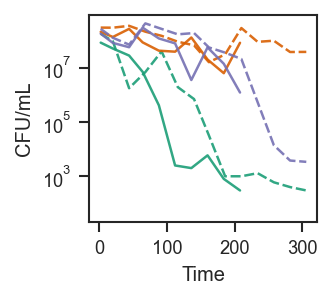

In [13]:
cp = sns.relplot(data=ct[(ct['plate'] == 'KAN') &
                         (ct['short'].isin(short))],
                 x='time',
                 y='CFU/mL',
                 hue='plasmid',
                 hue_order=order,
                 palette='Dark2',
                 style='replicate',
                 style_order=['1', '2'],
                 kind='line',
                 height=2.225, aspect=0.98,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel='CFU/mL',
       xlabel='Time',
       ylim=(20, 9E8),
       xlim=(np.float64(-15.251309999999998), np.float64(321.74674333333326))
      )

# cp.map(plt.axhline, y=90,
#        color='grey',
#        zorder=-1,
#        linestyle='--')
cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('pvb_counting_kan.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pvb_counting_kan.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

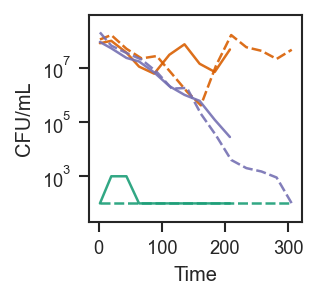

In [14]:
cp = sns.relplot(data=ct[(ct['plate'] == 'AMP') &
                         (ct['short'].isin(short))],
                 x='time',
                 y='CFU/mL',
                 hue='plasmid',
                 hue_order=order,
                 palette='Dark2',
                 style='replicate',
                 style_order=['1', '2'],
                 kind='line',
                 height=2.225, aspect=0.98,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel='CFU/mL',
       xlabel='Time',
       ylim=(20, 9E8),
       xlim=(np.float64(-15.251309999999998), np.float64(321.74674333333326)),
       xticks=[0, 100, 200, 300],
      )

# cp.map(plt.axhline, y=90,
#        color='grey',
#        zorder=-1,
#        linestyle='--')
cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('pvb_counting_amp.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pvb_counting_amp.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [15]:
# manuscript: time at which the culture drops below OD 0.3 after its peak
for (s, r), g in m1[m1['short'].isin(short)].groupby(['short', 'replicate']):
    g = g.sort_values('time')
    tpk = g.loc[g['smooth_od'].idxmax(), 'time']
    after = g[(g['time'] > tpk) & (g['smooth_od'] < 0.3)]
    print(s, r, 'peak', round(tpk, 1), 'below 0.3 at',
          round(after['time'].iloc[0], 1) if len(after) else 'never')

KAN 16x MIC 1 peak 8.3 below 0.3 at 42.9
KAN 16x MIC 2 peak 0.1 below 0.3 at 33.6
PVB 16x MIC 1 peak 81.6 below 0.3 at 203.4
PVB 16x MIC 2 peak 68.8 below 0.3 at 245.4
PVI 16x MIC 1 peak 144.0 below 0.3 at never
PVI 16x MIC 2 peak 47.5 below 0.3 at never
